## **Import all Libraries**

In [1]:
# ===============================
# Core Python & Utilities
# ===============================
import os
import io
import time
import math
import re
import random
import base64
from datetime import datetime
from typing import Tuple
from contextlib import redirect_stdout
from io import BytesIO
import heapq
from heapq import heappop, heappush

# ===============================
# Numerical & Data Handling
# ===============================
import numpy as np
import pandas as pd

# ===============================
# Visualization
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.figure import Figure
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D  # noqa
import colorsys

# ===============================
# Machine Learning - sklearn
# ===============================
from sklearn.datasets import make_blobs
from scipy.cluster import hierarchy
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    homogeneity_score,
    completeness_score,
    fowlkes_mallows_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
    v_measure_score,
    pairwise_distances
)

# ===============================
# Distance / Scientific Computing
# ===============================
from scipy.spatial import ConvexHull, distance


# ===============================
# Distance / Scientific Computing
# ===============================
from scipy.spatial.distance import cdist
from scipy.spatial.distance import pdist, squareform
from scipy.spatial.distance import euclidean
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics import pairwise_distances

# ===============================
# PDF / HTML Rendering
# ===============================
# from xhtml2pdf import pisa
from IPython.display import display, HTML, Markdown

# ===============================
# Google Colab (Optional)
# ===============================
import shutil
try:
    from google.colab import files
    COLAB_AVAILABLE = True
except ImportError:
    COLAB_AVAILABLE = False

# ===============================
# GUI File Dialog (Optional)
# ===============================
try:
    from tkinter import Tk
    from tkinter.filedialog import askopenfilename
    TK_AVAILABLE = True
except ImportError:
    TK_AVAILABLE = False

# Explicitly define SKLEARN_AVAILABLE as it's used in Plot class
SKLEARN_AVAILABLE = True

## class **DatasetLoader**

In [5]:
class DatasetLoader:

    def __init__(self, target_label, feature_array=None, use_colab_flag="n", dataset_nick_name=None):
        self.target_label = target_label
        self.feature_array = feature_array
        self.use_colab_flag = use_colab_flag.lower()
        self.dataset_nick_name = dataset_nick_name

        self.X = None
        self.true_labels = None
        self.file_name = None
        self.processed_feature_names = None

    def generate_data(self, n_features, n_datapoints, n_clusters,
                      cluster_std=1.0, random_state=42):

        X, true_labels = make_blobs(
            n_samples=n_datapoints,
            n_features=n_features,
            centers=n_clusters,
            cluster_std=cluster_std,
            random_state=random_state
        )

        self.X = X
        self.true_labels = true_labels
        self.file_name = "Randomly Generated"
        self.processed_feature_names = [f"Feature_{i}" for i in range(n_features)]

        return self.X, self.true_labels, self.file_name

    def upload_and_load(self):

        choice = input(
            "Select dataset source:\n"
            "Enter 0 for a randomly generated dataset\n"
            "Enter 1 to load your own dataset\n"
            "Your choice: "
        ).strip()

        # ---------------- RANDOM DATASET ----------------
        if choice == "0":
            n_features = int(input("Enter number of features: "))
            n_datapoints = int(input("Enter number of datapoints: "))
            n_clusters = int(input("Enter number of clusters: "))

            return self.generate_data(
                n_features=n_features,
                n_datapoints=n_datapoints,
                n_clusters=n_clusters
            )

        # ---------------- USER DATASET ----------------
        elif choice == "1":

            # --- FILE UPLOAD LOGIC ---
            if self.use_colab_flag == "y":
                uploaded = files.upload()
                if len(uploaded) != 1:
                    raise ValueError("Upload exactly one file.")
                self.file_name, file_bytes = next(iter(uploaded.items()))

            elif self.use_colab_flag == "n":
                Tk().withdraw()
                file_path = askopenfilename(
                    filetypes=[("CSV files", "*.csv"), ("Text files", "*.txt")]
                )
                if not file_path:
                    raise ValueError("No file selected.")
                self.file_name = file_path.split("/")[-1]
                with open(file_path, "rb") as f:
                    file_bytes = f.read()
            else:
                raise ValueError("use_colab_flag must be 'y' or 'n'")

            # --- PARSE DATAFRAME ---
            file_ext = self.file_name.split(".")[-1].lower()
            if file_ext == "csv":
                df = pd.read_csv(BytesIO(file_bytes))
            elif file_ext == "txt":
                df = pd.read_csv(BytesIO(file_bytes), sep=None, engine="python")
            else:
                raise ValueError("Unsupported file format. Use CSV or TXT only.")

            # --- VALIDATE COLUMNS ---
            if self.target_label not in df.columns:
                raise ValueError(f"Target column '{self.target_label}' not found")

            if self.feature_array is None:
                self.feature_array = [c for c in df.columns if c != self.target_label]

            missing = set(self.feature_array) - set(df.columns)
            if missing:
                raise ValueError(f"Missing feature columns: {missing}")

            # --- 1. HANDLE FEATURES (X) -> ONE HOT ENCODING ---
            X_df = df[self.feature_array]

            # This converts categorical features (strings) into binary 0/1 columns
            X_encoded_df = pd.get_dummies(X_df, dtype=int)

            self.X = X_encoded_df.to_numpy()
            self.processed_feature_names = X_encoded_df.columns.tolist()


            # --- 2. HANDLE TARGETS (Y) -> LABEL ENCODING ---
            # Metrics need 1D arrays. We use factorize to turn ['cat', 'dog', 'cat'] into [0, 1, 0]
            y_series = df[self.target_label]

            if y_series.dtype == 'object' or str(y_series.dtype) == 'category':
                # pd.factorize returns (codes, uniques). We only need codes for the array.
                codes, uniques = pd.factorize(y_series)
                self.true_labels = codes
                print(f"Note: Target '{self.target_label}' encoded as integers: {list(enumerate(uniques))}")
            else:
                self.true_labels = y_series.to_numpy()

            return self.X, self.true_labels, self.file_name

        else:
            raise ValueError("Invalid choice. Enter 0 or 1.")

    def print_dataset_details(self):

        if self.X is None or self.true_labels is None:
            raise RuntimeError("Dataset not loaded. Call upload_and_load() first.")

        # Since we forced labels to be 1D integers using factorize/numpy,
        # we can simply use set() to count them.
        unique_labels = sorted(set(self.true_labels))
        num_clusters = len(unique_labels)

        if num_clusters > 10:
            cluster_names = f"{unique_labels[:5]} ... {unique_labels[-5:]}"
        else:
            cluster_names = str(unique_labels)

        rows = [
            ("File Name", self.file_name),
            ("Dataset Shape", self.X.shape),
            ("Number of Datapoints", self.X.shape[0]),
            ("Number of Features", self.X.shape[1]),
            ("Number of Clusters", num_clusters),
            ("Cluster Names", cluster_names),
        ]

        left_width = max(len(label) for label, _ in rows) + 2
        right_width = max(len(str(value)) for _, value in rows) + 2

        horizontal = "+" + "-" * left_width + "+" + "-" * right_width + "+"

        print(horizontal)
        for label, value in rows:
            print(
                "| " + label.ljust(left_width - 1)
                + "| " + str(value).ljust(right_width - 1) + "|"
            )
            print(horizontal)

    def dataset_details_to_dataframe(self):
        if self.X is None or self.true_labels is None:
            raise RuntimeError("Dataset not loaded. Call upload_and_load() first.")

        unique_labels = sorted(set(self.true_labels))
        num_clusters = len(unique_labels)
        cluster_names = str(unique_labels)

        rows = [
            ("File Name", self.file_name),
            ("Dataset Shape", self.X.shape),
            ("Number of Datapoints", self.X.shape[0]),
            ("Number of Features", self.X.shape[1]),
            ("Number of Clusters", num_clusters),
            ("Cluster Names", cluster_names),
        ]

        return pd.DataFrame(rows, columns=["Property", "Value"])

## class **Evaluate**

In [6]:
class Evaluate:
    def __init__(self, name, X, y_true, y_pred):
        self.name = name
        self.X = X
        self.y_true = y_true
        self.y_pred = y_pred

    @staticmethod
    def dunn_index(X, labels):
        unique_labels = np.unique(labels)
        clusters = [X[labels == l] for l in unique_labels]

        inter_dist = np.inf
        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                dist = np.min(euclidean_distances(clusters[i], clusters[j]))
                inter_dist = min(inter_dist, dist)

        intra_dist = 0.0
        for c in clusters:
            if len(c) > 1:
                intra_dist = max(intra_dist, np.max(euclidean_distances(c, c)))

        return inter_dist / intra_dist if intra_dist > 0 else 0.0

    @staticmethod
    def avg_euclidean_to_centroid(X, labels):
        unique_labels = np.unique(labels)
        dists = []
        for l in unique_labels:
            cluster = X[labels == l]
            centroid = cluster.mean(axis=0)
            dists.append(np.mean(np.linalg.norm(cluster - centroid, axis=1)))
        return float(np.mean(dists))

    def metrics_(self):
        return {
            "Method": self.name,

            # Internal Metrics
            "Silhouette": silhouette_score(self.X, self.y_pred),
            "Davies-Bouldin": davies_bouldin_score(self.X, self.y_pred),
            "Calinski-Harabasz": calinski_harabasz_score(self.X, self.y_pred),
            "Dunn Index": self.dunn_index(self.X, self.y_pred),
            "Avg Euclidean to Centroid": self.avg_euclidean_to_centroid(self.X, self.y_pred),

            # External Metrics
            "Homogeneity": homogeneity_score(self.y_true, self.y_pred),
            "Completeness": completeness_score(self.y_true, self.y_pred),
            "V-Measure": v_measure_score(self.y_true, self.y_pred),
            "Fowlkes-Mallows": fowlkes_mallows_score(self.y_true, self.y_pred),
            "Adjusted Rand Index": adjusted_rand_score(self.y_true, self.y_pred),
            "Adjusted Mutual Info": adjusted_mutual_info_score(self.y_true, self.y_pred),
        }

In [7]:
def bold(text):
    return f"\033[1m{text}\033[0m"

def print_eval_metrics_details():
    print(f"Silhouette (SH): {bold('Higher')} value indicates better clustering.")
    print(f"Davies–Bouldin (DB): {bold('Lower')} value indicates better clustering.")
    print(f"Calinski–Harabasz (CH): {bold('Higher')} value indicates better-defined clusters.")
    print(f"Dunn Index (DU): {bold('Higher')} value indicates better cluster separation and compactness.")
    print(f"Euclidean Distance (ED): {bold('Lower')} value means points are closer to each other.")
    print(f"Homogeneity (HM): {bold('Higher')} value means each cluster contains mostly one class.")
    print(f"Completeness (CM): {bold('Higher')} value means all points of a class are assigned to the same cluster.")
    print(f"V-measure: {bold('Higher')} value indicates a better balance of homogeneity and completeness.")
    print(f"Fowlkes–Mallows Index (FM): {bold('Higher')} value indicates better similarity to ground truth.")
    print(f"Adjusted Rand Index (ARI): {bold('Higher')} value indicates better agreement with true labels.")
    print(f"Adjusted Mutual Information (AMI): {bold('Higher')} value indicates stronger mutual agreement.")
    print(f"Time: {bold('Lower')} value indicates faster computation.")

## class **Plot**

In [8]:
class Plot:
    # Colors for cluster points
    DEFAULT_COLORS = [
        "#eb7434",  # orange
        "#35b86c",  # green
        "#3180e8",  # blue
        "#ae31e8",  # purple
        "#fcda2d",  # yellow
        "#f52a2a",  # red
        "#28dec9",  # cyan
        "#f536f5",  # magenta
        "#36c5f5",  # indigo
        "#8936ff",  # violet
    ]

    # ============================================================
    # Helper: Generate random colors
    # ============================================================
    @staticmethod
    def _extend_colors(n_needed, current_colors):
        colors = list(current_colors)
        existing_count = len(colors)
        if n_needed > existing_count:
            num_new = n_needed - existing_count
            for _ in range(num_new):
                h = random.random()
                s = 0.8 + (random.random() * 0.2)
                l = 0.5 + (random.random() * 0.1)
                r, g, b = colorsys.hls_to_rgb(h, l, s)
                new_color = "#{:02x}{:02x}{:02x}".format(int(r*255), int(g*255), int(b*255))
                colors.append(new_color)
        return colors

    # ============================================================
    # 1. Single Final Cluster Plot
    # ============================================================
    @staticmethod
    def plot_final_clusters(X, labels, colors=None, title="Cluster plot", figsize=(10, 8), alpha=1):
        X = np.asarray(X)

        # Handle None labels for single plot
        if labels is None:
            return Plot.plot_clusters_without_labels(X, title=title, figsize=figsize, alpha=alpha)

        labels = np.asarray(labels)
        unique_labels = np.unique(labels)
        n_clusters = len(unique_labels)
        n_features = X.shape[1]

        if colors is None:
            colors = Plot.DEFAULT_COLORS
        if len(colors) < n_clusters:
            colors = Plot._extend_colors(n_clusters, colors)
        cluster_cmap = ListedColormap(colors[:n_clusters])

        fig = None

        if n_features == 2:
            fig = plt.figure(figsize=figsize)
            for i, lab in enumerate(unique_labels):
                pts = X[labels == lab]
                plt.scatter(pts[:, 0], pts[:, 1], s=20, alpha=alpha, color=cluster_cmap(i), label=f"C{lab+1}")
            plt.title(title)
            plt.legend()

        elif n_features == 3:
            fig = plt.figure(figsize=figsize)
            ax = fig.add_subplot(111, projection="3d")
            for i, lab in enumerate(unique_labels):
                pts = X[labels == lab]
                ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=20, alpha=alpha, color=cluster_cmap(i), label=f"C{lab+1}")
            ax.set_title(title)
            ax.legend()

        else:
            pca = PCA(n_components=3)
            X_plot = pca.fit_transform(X)
            fig = plt.figure(figsize=figsize)
            ax = fig.add_subplot(111, projection="3d")
            for i, lab in enumerate(unique_labels):
                pts = X_plot[labels == lab]
                ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=20, alpha=alpha, color=cluster_cmap(i), label=f"C{lab+1}")
            ax.set_title(title)
            ax.legend()

        plt.tight_layout()
        plt.show()
        return fig

    # ============================================================
    # 2. Plot without labels
    # ============================================================
    @staticmethod
    def plot_clusters_without_labels(X, point_color="#999999", title="Data distribution", figsize=(10, 8), alpha=1):
        X = np.asarray(X)
        n_features = X.shape[1]
        fig = None

        if n_features == 2:
            fig = plt.figure(figsize=figsize)
            plt.scatter(X[:, 0], X[:, 1], s=20, alpha=alpha, color=point_color)
            plt.title(title)
        elif n_features == 3:
            fig = plt.figure(figsize=figsize)
            ax = fig.add_subplot(111, projection="3d")
            ax.scatter(X[:, 0], X[:, 1], X[:, 2], s=20, alpha=alpha, color=point_color)
            ax.set_title(title)
        else:
            pca = PCA(n_components=3)
            X_plot = pca.fit_transform(X)
            fig = plt.figure(figsize=figsize)
            ax = fig.add_subplot(111, projection="3d")
            ax.scatter(X_plot[:, 0], X_plot[:, 1], X_plot[:, 2], s=20, alpha=alpha, color=point_color)
            ax.set_title(title)

        plt.tight_layout()
        plt.show()
        return fig

    # ============================================================
    # 3. Subplots for Multiple Clustering Results
    # ============================================================
    @staticmethod
    def subplots_final_clusters(
        X,
        all_labels,
        plot_titles,
        no_of_subplots=8,
        subplot_fig_matrix=(4, 2),
        plot_figure_size=(15, 25)
    ):
        """
        Generates a grid of subplots.
        - If labels are None, plots raw data in gray.
        - Adds borders around every subplot.
        """
        X = np.asarray(X)
        n_features = X.shape[1]
        rows, cols = subplot_fig_matrix

        # Determine dimensionality and prepare data
        is_3d = False
        X_plot = X

        if n_features == 3:
            is_3d = True
        elif n_features > 3:
            is_3d = True
            pca = PCA(n_components=3)
            X_plot = pca.fit_transform(X)
            print(f"Note: Data reduced from {n_features}D to 3D via PCA for visualization.")

        # Create Subplots
        if is_3d:
            fig, axes = plt.subplots(rows, cols, figsize=plot_figure_size, subplot_kw={'projection': '3d'})
        else:
            fig, axes = plt.subplots(rows, cols, figsize=plot_figure_size)

        axes_flat = axes.flatten() if no_of_subplots > 1 else [axes]

        for i in range(no_of_subplots):
            ax = axes_flat[i]

            # 1. ADD BORDERS (Draw box around subplot)
            # ----------------------------------------
            if not is_3d:
                # For 2D, we can strictly style the spines
                for spine in ax.spines.values():
                    spine.set_visible(True)
                    spine.set_color('black')
                    spine.set_linewidth(1.5)
            else:
                # For 3D, spines are different, but we can set pane colors or box
                # Usually 3D plots have their own box, but we ensure the axis is on
                ax.axis('on')

            # Safety check for index
            if i >= len(all_labels):
                ax.axis('off')
                continue

            current_labels = all_labels[i]
            title = plot_titles[i] if i < len(plot_titles) else f"Plot {i+1}"

            # 2. HANDLE 'NONE' LABELS (Raw Data)
            # ----------------------------------
            if current_labels is None:
                if is_3d:
                    ax.scatter(X_plot[:, 0], X_plot[:, 1], X_plot[:, 2],
                               s=15, alpha=0.6, color='#999999') # Gray
                    ax.set_xlabel("X1")
                    ax.set_ylabel("X2")
                    ax.set_zlabel("X3")
                else:
                    ax.scatter(X_plot[:, 0], X_plot[:, 1],
                               s=15, alpha=0.6, color='#999999') # Gray
                    ax.set_xlabel("X1")
                    ax.set_ylabel("X2")

                ax.set_title(title, fontsize=12, fontweight='bold')
                continue # Skip the rest of the loop for this subplot

            # 3. PLOT CLUSTERS (If labels exist)
            # ----------------------------------
            labels = np.asarray(current_labels)
            unique_labels = np.unique(labels)
            n_clusters = len(unique_labels)

            colors = Plot.DEFAULT_COLORS
            if len(colors) < n_clusters:
                colors = Plot._extend_colors(n_clusters, colors)
            cluster_cmap = ListedColormap(colors[:n_clusters])

            if is_3d:
                for lbl_idx, lab in enumerate(unique_labels):
                    pts = X_plot[labels == lab]
                    ax.scatter(
                        pts[:, 0], pts[:, 1], pts[:, 2],
                        s=15, alpha=0.8, color=cluster_cmap(lbl_idx),
                        label=f"C{lab}"
                    )
                ax.set_xlabel("X1")
                ax.set_ylabel("X2")
                ax.set_zlabel("X3")
            else:
                for lbl_idx, lab in enumerate(unique_labels):
                    pts = X_plot[labels == lab]
                    ax.scatter(
                        pts[:, 0], pts[:, 1],
                        s=15, alpha=0.8, color=cluster_cmap(lbl_idx),
                        label=f"C{lab}"
                    )
                ax.set_xlabel("X1")
                ax.set_ylabel("X2")

            ax.set_title(title, fontsize=12, fontweight='bold')

            if n_clusters <= 10:
                ax.legend(fontsize=6, loc='best')

        # Hide unused axes
        for j in range(no_of_subplots, len(axes_flat)):
            axes_flat[j].axis('off')

        plt.tight_layout()
        plt.show()

        return fig

## class **HullAverageLinkage**

In [9]:
class HullAverageLinkage:
    def __init__(self, n_clusters=2, feature_threshold=5, max_hull_points=10):
        self.n_clusters = n_clusters
        self.feature_threshold = feature_threshold
        self.max_hull_points = max_hull_points
        self.labels_ = None

    def _get_boundary_points(self, candidate_points):
        """
        Efficiently computes the boundary/hull of a set of points.
        """
        n_points, n_features = candidate_points.shape

        # Case 1: Too few points for hull
        if n_points <= n_features + 1:
            return candidate_points

        # Case 2: High Dimensions -> Furthest Point Approximation
        if n_features >= self.feature_threshold:
            # If candidate_points are already few, just keep them
            if n_points <= self.max_hull_points:
                return candidate_points

            center = np.mean(candidate_points, axis=0)
            dists = np.linalg.norm(candidate_points - center, axis=1)

            k = min(n_points, self.max_hull_points)
            idx = np.argpartition(dists, -k)[-k:]
            return candidate_points[idx]

        # Case 3: Low Dimensions-> Exact Convex Hull
        try:
            hull = ConvexHull(candidate_points)
            return candidate_points[hull.vertices]
        except Exception:
            return candidate_points

    def fit_predict(self, X):
        n_datapoints = X.shape[0]

        # Initialize self.labels_ as a numpy array
        self.labels_ = np.zeros(n_datapoints, dtype=int)

        # --- 1. Cluster State Initialization ---

        # Every data point starts as its own individual cluster
        boundary_points_map = {i: X[[i]] for i in range(n_datapoints)}


        # --- 2. Initial All-Pairs Distance Calculation ---

        # Euclidean Distance
        distance_matrix = pdist(X, metric='euclidean')

        # Heap Construction
        min_dist_heap = []
        idx = 0
        for i in range(n_datapoints):
            for j in range(i + 1, n_datapoints):
                d = distance_matrix[idx]
                idx += 1
                min_dist_heap.append((d, i, j))

        heapq.heapify(min_dist_heap)

        # Registry & Tracker Setup
        active_cluster_ids = set(range(n_datapoints))
        cluster_membership_map = {i: [i] for i in range(n_datapoints)}
        next_cluster_id = n_datapoints

        # --- 3. Loop untill no of active clusters > no of desired clusters ---
        while len(active_cluster_ids) > self.n_clusters:

            # - 3.1. Finding the Closest Pair -
            found_pair = False
            id1, id2, dist = -1, -1, np.inf

            while min_dist_heap:
                d, u, v = heapq.heappop(min_dist_heap)
                if u in active_cluster_ids and v in active_cluster_ids:
                    id1, id2, dist = u, v, d
                    found_pair = True
                    break

            if not found_pair: break

            # - 3.2. Merge & Creating the New Group -
            new_id = next_cluster_id
            next_cluster_id += 1

            # - 3.3. Hull of Hulls -
            boundary_points_1 = boundary_points_map[id1]
            boundary_points_2 = boundary_points_map[id2]
            combined_boundary_points = np.vstack([boundary_points_1, boundary_points_2])

            # - 3.4. Get boundary points -
            boundary_points_map[new_id] = self._get_boundary_points(combined_boundary_points)

            # - 3.5. Updating State & History -

            # Merge & Updating the 'Membership List'
            cluster_membership_map[new_id] = cluster_membership_map[id1] + cluster_membership_map[id2]

            # Cleanup Old
            active_cluster_ids.remove(id1)
            active_cluster_ids.remove(id2)
            del boundary_points_map[id1], boundary_points_map[id2]
            del cluster_membership_map[id1], cluster_membership_map[id2]

            # Grabbing the New Shape
            new_boundary_points = boundary_points_map[new_id]
            active_list = list(active_cluster_ids)

            # - 3.6. Measuring New Distances -

            for other_id in active_list:
                other_boundary_points = boundary_points_map[other_id]

                update_dist_matrix = cdist(new_boundary_points, other_boundary_points, metric='euclidean')
                d = np.mean(update_dist_matrix)

                heapq.heappush(min_dist_heap, (d, other_id, new_id))

            active_cluster_ids.add(new_id)

        # - 4. Final Label Assignment -
        for final_label, c_id in enumerate(active_cluster_ids):
            for original_idx in cluster_membership_map[c_id]:
                self.labels_[original_idx] = final_label

        return self.labels_

## class **HullCentroidLinkage**

In [10]:
class HullCentroidLinkage:
    def __init__(self, n_clusters=2, feature_threshold=5, max_hull_points=10):
        self.n_clusters = n_clusters
        self.feature_threshold = feature_threshold
        self.max_hull_points = max_hull_points
        self.labels_ = None
        self.merge_history = []

    def _get_centroids_and_boundary_points(self, candidates_points):
        """
        Calculates 'Hull Centroid' and subsets the boundary points.
        """
        n_points, n_features = candidates_points.shape

        # Case 1: Single Point -> Instant return
        if n_points == 1:
            return candidates_points[0], candidates_points

        # Case 2: High Dimensions OR Too few points for Hull -> Outer shell or Furthest Point Approximation
        if n_features >= self.feature_threshold or n_points <= n_features + 1:
            # If we have fewer points than the requested reps, return them all
            if n_points <= self.max_hull_points:
                return np.mean(candidates_points, axis=0), candidates_points

            # Otherwise, filter furthest points
            center = np.mean(candidates_points, axis=0)
            update_dists = np.linalg.norm(candidates_points - center, axis=1)

            k = self.max_hull_points
            idx = np.argpartition(update_dists, -k)[-k:]
            boundary_points = candidates_points[idx]

            return np.mean(boundary_points, axis=0), boundary_points

        # Case 3: Low Dimensions -> Exact Convex Hull
        try:
            hull = ConvexHull(candidates_points)
            hull_points = candidates_points[hull.vertices]
            return np.mean(hull_points, axis=0), hull_points
        except Exception:
            return np.mean(candidates_points, axis=0), candidates_points

    def fit_predict(self, X):
        n_datapoints = X.shape[0]

        # --- 1. Cluster State Initialization ---
        # Every data point starts as its own individual cluster
        active_clusters = {}
        for i in range(n_datapoints):
            pt = X[i:i+1]
            active_clusters[i] = (X[i], pt, 1)

        # --- 2. Initial All-Pairs Distance Calculation ---

        # Euclidean Distance
        distance_matrix = pdist(X, metric='euclidean')

        # Heap Construction
        min_dist_heap = []
        idx = 0
        for i in range(n_datapoints):
            for j in range(i + 1, n_datapoints):
                d = distance_matrix[idx]
                idx += 1
                heapq.heappush(min_dist_heap, (d, i, j))

        # Registry & Tracker Setup
        active_cluster_ids = set(range(n_datapoints))
        cluster_membership_map = {i: [i] for i in range(n_datapoints)}
        next_cluster_id = n_datapoints

        # --- 3. Loop untill no of active clusters > no of desired clusters ---
        while len(active_cluster_ids) > self.n_clusters:
            if not min_dist_heap:
                break

            # - 3.1. Pick the Closest Pair -
            dist, id1, id2 = heapq.heappop(min_dist_heap)

            # - 3.2. Check if id1 and id2 are still alive -
            if id1 not in active_cluster_ids or id2 not in active_cluster_ids:
                continue

            # - 3.3. Merging Representatives (Hull of Hulls) -

            # Retrieve data for the two clusters being merged
            centroid_1, boundary_1, size_1 = active_clusters[id1]
            centroid_2, boundary_2, size_2 = active_clusters[id2]

            # Combine the boundary points
            combined_boundary_points = np.vstack([boundary_1, boundary_2])

            # Compute geometry for the new merge cluster
            new_centroids, new_boundaries = self._get_centroids_and_boundary_points(combined_boundary_points)
            new_size = size_1 + size_2
            new_id = next_cluster_id
            next_cluster_id += 1

            # - 3.4. Updating State & History -
            # Register the new cluster
            active_clusters[new_id] = (new_centroids, new_boundaries, new_size)

            # Mapping Update
            active_cluster_ids.add(new_id)

            # Merge the lists of point indices
            cluster_membership_map[new_id] = cluster_membership_map[id1] + cluster_membership_map[id2]

            # Cleanup old
            active_cluster_ids.remove(id1)
            active_cluster_ids.remove(id2)
            del active_clusters[id1], active_clusters[id2]
            del cluster_membership_map[id1], cluster_membership_map[id2]

            # Record History
            self.merge_history.append([id1, id2, dist, new_size])

            # Get list of current valid IDs (excluding the new one)
            current_active = list(active_cluster_ids)
            current_active.remove(new_id)

            if not current_active:
                continue

            # - 3.5. Calculate New Distances -

            # Create matrix of other centroids
            other_centroids = np.array([active_clusters[i][0] for i in current_active])

            # Vectorized Norm calculation
            update_dists = np.linalg.norm(other_centroids - new_centroids, axis=1)

            # Push new edges to heap
            for i, other_id in enumerate(current_active):
                d = update_dists[i]
                heapq.heappush(min_dist_heap, (d, min(new_id, other_id), max(new_id, other_id)))

        # - 4. Final Label Assignment -
        self.labels_ = np.zeros(n_datapoints, dtype=int)
        final_clusters = list(cluster_membership_map.values())

        # Assign final labels 0 to K-1
        for label_id, points in enumerate(final_clusters):
            self.labels_[points] = label_id

        return self.labels_

## **Main**

### ***Dataset Input***

In [13]:
#================== Dataset Upload, Load & Parse ===================
dataset_name = str(input("Enter a name for this Dataset: "))

use_colab_flag = input(
        "Are you currently using Google Colab? (Y - Yes / N - No): ").strip().lower()
dataset = DatasetLoader(target_label="Class", use_colab_flag=use_colab_flag,
        dataset_nick_name=dataset_name)
X, true_labels, file_name = dataset.upload_and_load()

n_true_clusters = len(np.unique(true_labels))
n_datapoints = X.shape[0]

dataset.print_dataset_details()

Enter a name for this Dataset: Random
Are you currently using Google Colab? (Y - Yes / N - No): Y
Select dataset source:
Enter 0 for a randomly generated dataset
Enter 1 to load your own dataset
Your choice: 0
Enter number of features: 2
Enter number of datapoints: 100
Enter number of clusters: 5
+----------------------+-------------------------------------------------------------------+
| File Name            | Randomly Generated                                                |
+----------------------+-------------------------------------------------------------------+
| Dataset Shape        | (100, 2)                                                          |
+----------------------+-------------------------------------------------------------------+
| Number of Datapoints | 100                                                               |
+----------------------+-------------------------------------------------------------------+
| Number of Features   | 2                         

### ***Evaluate***

In [14]:
k = n_true_clusters
# n_runs = 1
feature_threshold=10
max_hull_points=20
evaluation_table = []

In [15]:
start_time_single_linkage = time.time()
single_linkage_model = AgglomerativeClustering(n_clusters=k,metric='euclidean',linkage='single')
labels_single = single_linkage_model.fit_predict(X)
end_time_single_linkage = time.time()

eval_single_linkage = Evaluate("Single Linkage", X, true_labels, labels_single).metrics_()
evaluation_table.append(eval_single_linkage)

time_single_linkage= (end_time_single_linkage - start_time_single_linkage)

In [16]:
start_time_complete_linkage = time.time()
complete_linkage_model = AgglomerativeClustering(n_clusters=k,metric='euclidean',linkage='complete')
labels_complete = complete_linkage_model.fit_predict(X)
end_time_complete_linkage = time.time()

eval_complete_linkage = Evaluate("Complete Linkage", X, true_labels, labels_complete).metrics_()
evaluation_table.append(eval_complete_linkage)

time_complete_linkage= (end_time_complete_linkage - start_time_complete_linkage)

In [17]:
start_time_average_linkage = time.time()
average_linkage_model = AgglomerativeClustering(n_clusters=k,metric='euclidean',linkage='average')
labels_average = average_linkage_model.fit_predict(X)
end_time_average_linkage = time.time()

eval_average_linkage = Evaluate("Average Linkage", X, true_labels, labels_average).metrics_()
evaluation_table.append(eval_average_linkage)

time_average_linkage= (end_time_average_linkage - start_time_average_linkage)

In [18]:
start_time_ward_linkage = time.time()
ward_linkage_model = AgglomerativeClustering(n_clusters=k,metric='euclidean',linkage='ward')
labels_ward = ward_linkage_model.fit_predict(X)
end_time_ward_linkage = time.time()

eval_ward_linkage = Evaluate("Ward Linkage", X, true_labels, labels_ward).metrics_()
evaluation_table.append(eval_ward_linkage)

time_ward_linkage= (end_time_ward_linkage - start_time_ward_linkage)

In [19]:
start_time_hull_avg_linkage = time.time()
hull_avg_model = HullAverageLinkage(n_clusters=k)
labels_hull_avg = hull_avg_model.fit_predict(X)
end_time_hull_avg_linkage = time.time()

eval_hull_avg_linkage = Evaluate("Hull Average Linkage", X, true_labels, labels_hull_avg).metrics_()
evaluation_table.append(eval_hull_avg_linkage)

time_hull_avg_linkage= (end_time_hull_avg_linkage - start_time_hull_avg_linkage)

In [20]:
start_time_hull_cen_linkage = time.time()
hull_cen_model = HullCentroidLinkage(n_clusters=k)
labels_hull_cen = hull_cen_model.fit_predict(X)
end_time_hull_cen_linkage = time.time()

eval_hull_cen_linkage = Evaluate("Hull Centroid Linkage", X, true_labels, labels_hull_cen).metrics_()
evaluation_table.append(eval_hull_cen_linkage)

time_hull_cen_linkage= (end_time_hull_cen_linkage - start_time_hull_cen_linkage)

In [21]:
print_eval_metrics_details()

table = pd.DataFrame(evaluation_table)


table["Time(Sec)"] = [time_single_linkage, time_complete_linkage, time_average_linkage, time_ward_linkage, time_hull_avg_linkage, time_hull_cen_linkage]

cols = ['Method'] + [col for col in table.columns if col != 'Method']
table = table[cols]

table.insert(0, "Dataset", dataset_name)

table_round3 = table.round(3)

display(table_round3)

Silhouette (SH): Higher value indicates better clustering.
Davies–Bouldin (DB): Lower value indicates better clustering.
Calinski–Harabasz (CH): Higher value indicates better-defined clusters.
Dunn Index (DU): Higher value indicates better cluster separation and compactness.
Euclidean Distance (ED): Lower value means points are closer to each other.
Homogeneity (HM): Higher value means each cluster contains mostly one class.
Completeness (CM): Higher value means all points of a class are assigned to the same cluster.
V-measure: Higher value indicates a better balance of homogeneity and completeness.
Fowlkes–Mallows Index (FM): Higher value indicates better similarity to ground truth.
Adjusted Rand Index (ARI): Higher value indicates better agreement with true labels.
Adjusted Mutual Information (AMI): Higher value indicates stronger mutual agreement.
Time: Lower value indicates faster computation.


,Dataset,Method,Silhouette,Davies-Bouldin,Calinski-Harabasz,Dunn Index,Avg Euclidean to Centroid,Homogeneity,Completeness,V-Measure,Fowlkes-Mallows,Adjusted Rand Index,Adjusted Mutual Info,Time(Sec)
0,Random,Single Linkage,0.694,0.43,842.945,0.351,1.143,0.975,0.975,0.975,0.979,0.975,0.974,0.001
1,Random,Complete Linkage,0.694,0.43,842.945,0.351,1.143,0.975,0.975,0.975,0.979,0.975,0.974,0.001
2,Random,Average Linkage,0.694,0.43,842.945,0.351,1.143,0.975,0.975,0.975,0.979,0.975,0.974,0.001
3,Random,Ward Linkage,0.694,0.43,842.945,0.351,1.143,0.975,0.975,0.975,0.979,0.975,0.974,0.001
4,Random,Hull Average Linkage,0.694,0.43,842.945,0.351,1.143,0.975,0.975,0.975,0.979,0.975,0.974,0.046
5,Random,Hull Centroid Linkage,0.694,0.43,842.945,0.351,1.143,0.975,0.975,0.975,0.979,0.975,0.974,0.016


In [ ]:
table_save = table_round3.copy()
save_filename = f"{dataset_name}_RESULT.csv"
table_save.to_csv(save_filename, index=True)
files.download(save_filename)

### ***Plot***

In [ ]:
dpi = 300
plot_folder_name = f'{dataset_name}_plots'
os.makedirs(plot_folder_name, exist_ok=True)
saveplotpath = f'./{plot_folder_name}/{dataset_name}'

In [ ]:
raw_data_dist_plot = Plot.plot_clusters_without_labels(X, title="Raw Data Distribution")
raw_data_dist_plot.savefig(f'{saveplotpath}_raw_data_dist_plot.png', dpi=dpi)

In [ ]:
true_labels_plot = Plot.plot_final_clusters(X, true_labels, title="True Labels")
raw_data_dist_plot.savefig(f'{saveplotpath}_true_labels_plot.png', dpi=dpi)

In [ ]:
single_linkage_plot = Plot.plot_final_clusters(X,labels_single,title="Single Linkage")
single_linkage_plot.savefig(f'{saveplotpath}_single_linkage_plot.png', dpi=dpi)

In [ ]:
complete_linkage_plot = Plot.plot_final_clusters(X,labels_complete,title="Complete Linkage")
complete_linkage_plot.savefig(f'{saveplotpath}_complete_linkage_plot.png', dpi=dpi)

In [ ]:
average_linkage_plot = Plot.plot_final_clusters(X,labels_average,title="Average Linkage")
average_linkage_plot.savefig(f'{saveplotpath}_average_linkage_plot.png', dpi=dpi)

In [ ]:
ward_linkage_plot = Plot.plot_final_clusters(X,labels_ward,title="Ward Linkage")
ward_linkage_plot.savefig(f'{saveplotpath}_ward_linkage_plot.png', dpi=dpi)

In [ ]:
hull_avg_linkage_plot = Plot.plot_final_clusters(X,labels_hull_avg,title="Hull Average Linkage")
hull_avg_linkage_plot.savefig(f'{saveplotpath}_hull_avg_linkage_plot.png', dpi=dpi)

In [ ]:
hull_cen_linkage_plot = Plot.plot_final_clusters(X,labels_hull_cen,title="Hull Centroid Linkage")
hull_cen_linkage_plot.savefig(f'{saveplotpath}_hull_cen_linkage_plot.png', dpi=dpi)

In [ ]:
all_labels = [None, true_labels, labels_single, labels_complete, labels_average, labels_ward, labels_hull_avg, labels_hull_cen]
plot_titles = ["Raw Data Distribution", "True Labels", "Single Linkage", "Complete Linkage", "Average Linkage", "Ward Linkage", "Hull Average Linkage", "Hull Centroid Linkage"]

subplot_fig = Plot.subplots_final_clusters(X,all_labels,plot_titles,no_of_subplots=8,subplot_fig_matrix=(4, 2),plot_figure_size=(15, 25))

subplot_fig.savefig(f'{saveplotpath}_all_subplots.png', dpi=dpi)

In [ ]:
shutil.make_archive(plot_folder_name, 'zip', plot_folder_name)
files.download(f'{plot_folder_name}.zip')

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy

def plot_simplified_dendrogram(X, method='ward', p=30, title="Simplified Dendrogram", figsize=(12, 6)):
    """
    Generates a simplified dendrogram for large datasets.

    Parameters:
    - X: The feature array/dataset.
    - method: The linkage method to use ('ward', 'single', 'complete', 'average').
    - p: The number of top clusters/leaves to display.
    - title: Title of the plot.
    - figsize: Figure size (width, height).
    """
    X = np.asarray(X)

    # Calculate the standard linkage matrix
    Z = hierarchy.linkage(X, method=method, metric='euclidean')

    fig = plt.figure(figsize=figsize)
    plt.title(title, fontsize=14, fontweight='bold')

    # The x-axis will show cluster sizes in parentheses
    plt.xlabel("Number of points in node (or point index if no parenthesis)", fontsize=10)
    plt.ylabel("Distance", fontsize=10)

    # Generate the truncated dendrogram
    hierarchy.dendrogram(
        Z,
        truncate_mode='lastp',  # Show only the last 'p' merged clusters
        p=p,                    # Target number of leaves
        leaf_rotation=90.,      # Rotate labels for readability
        leaf_font_size=12.,
        show_contracted=True    # Places a dot to indicate a truncated branch
    )

    plt.tight_layout()
    plt.show()
    return fig

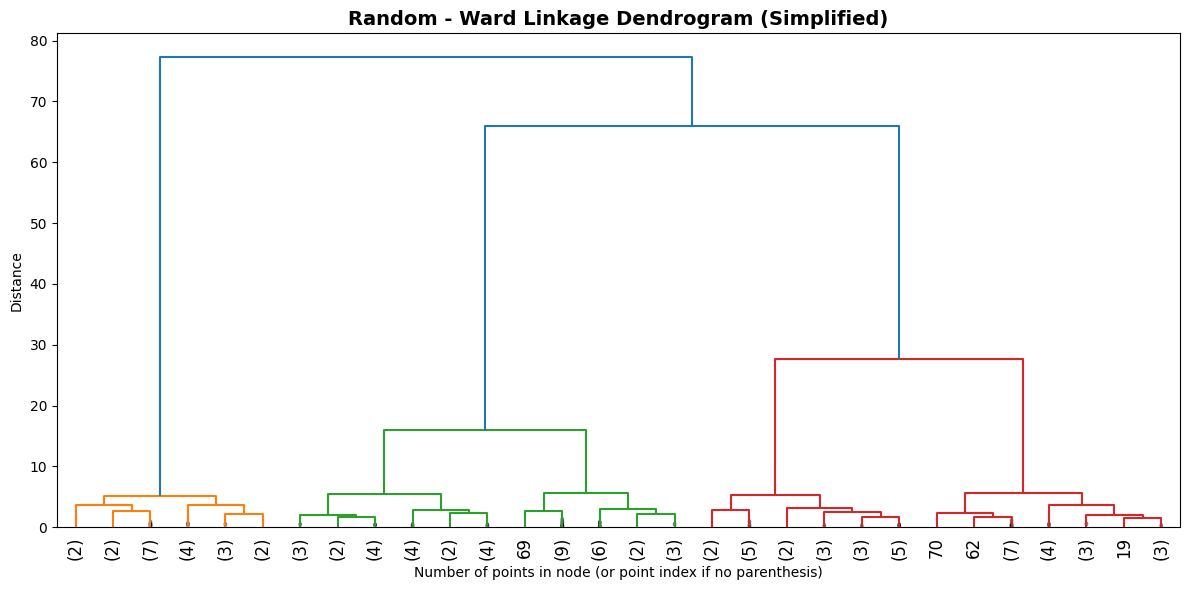

NameError: name 'saveplotpath' is not defined

In [24]:
# Create a simplified Ward Linkage dendrogram showing only the top 30 clusters
ward_dendrogram_plot = plot_simplified_dendrogram(
    X,
    method='ward',
    p=30,
    title=f"{dataset_name} - Ward Linkage Dendrogram (Simplified)"
)

# Save the plot
ward_dendrogram_plot.savefig(f'{saveplotpath}_ward_dendrogram_plot.png', dpi=dpi)

# Example for Average Linkage
avg_dendrogram_plot = plot_simplified_dendrogram(
    X,
    method='average',
    p=30,
    title=f"{dataset_name} - Average Linkage Dendrogram (Simplified)"
)
avg_dendrogram_plot.savefig(f'{saveplotpath}_average_dendrogram_plot.png', dpi=dpi)

In [26]:
import numpy as np
import heapq
from scipy.spatial import ConvexHull
from scipy.spatial.distance import pdist, cdist
# import matplotlib.subplots as plt
from scipy.cluster import hierarchy

# ============================================================
# 1. Hull Average Linkage (Updated with merge_history)
# ============================================================
class HullAverageLinkage:
    def __init__(self, n_clusters=2, feature_threshold=5, max_hull_points=10):
        self.n_clusters = n_clusters
        self.feature_threshold = feature_threshold
        self.max_hull_points = max_hull_points
        self.labels_ = None
        self.merge_history = []  # <--- ADDED

    def _get_boundary_points(self, candidate_points):
        """
        Efficiently computes the boundary/hull of a set of points.
        """
        n_points, n_features = candidate_points.shape

        # Case 1: Too few points for hull
        if n_points <= n_features + 1:
            return candidate_points

        # Case 2: High Dimensions -> Furthest Point Approximation
        if n_features >= self.feature_threshold:
            # If candidate_points are already few, just keep them
            if n_points <= self.max_hull_points:
                return candidate_points

            center = np.mean(candidate_points, axis=0)
            dists = np.linalg.norm(candidate_points - center, axis=1)

            k = min(n_points, self.max_hull_points)
            idx = np.argpartition(dists, -k)[-k:]
            return candidate_points[idx]

        # Case 3: Low Dimensions-> Exact Convex Hull
        try:
            hull = ConvexHull(candidate_points)
            return candidate_points[hull.vertices]
        except Exception:
            return candidate_points

    def fit_predict(self, X):
        n_datapoints = X.shape[0]

        # Initialize self.labels_ as a numpy array
        self.labels_ = np.zeros(n_datapoints, dtype=int)

        # --- 1. Cluster State Initialization ---

        # Every data point starts as its own individual cluster
        boundary_points_map = {i: X[[i]] for i in range(n_datapoints)}


        # --- 2. Initial All-Pairs Distance Calculation ---

        # Euclidean Distance
        distance_matrix = pdist(X, metric='euclidean')

        # Heap Construction
        min_dist_heap = []
        idx = 0
        for i in range(n_datapoints):
            for j in range(i + 1, n_datapoints):
                d = distance_matrix[idx]
                idx += 1
                min_dist_heap.append((d, i, j))

        heapq.heapify(min_dist_heap)

        # Registry & Tracker Setup
        active_cluster_ids = set(range(n_datapoints))
        cluster_membership_map = {i: [i] for i in range(n_datapoints)}
        next_cluster_id = n_datapoints

        # <--- ADDED: Track cluster sizes for the dendrogram --->
        cluster_size_map = {i: 1 for i in range(n_datapoints)}

        # --- 3. Loop untill no of active clusters > no of desired clusters ---
        while len(active_cluster_ids) > self.n_clusters:

            # - 3.1. Finding the Closest Pair -
            found_pair = False
            id1, id2, dist = -1, -1, np.inf

            while min_dist_heap:
                d, u, v = heapq.heappop(min_dist_heap)
                if u in active_cluster_ids and v in active_cluster_ids:
                    id1, id2, dist = u, v, d
                    found_pair = True
                    break

            if not found_pair: break

            # - 3.2. Merge & Creating the New Group -
            new_id = next_cluster_id
            next_cluster_id += 1

            # <--- ADDED: Calculate new size and save to history --->
            new_size = cluster_size_map[id1] + cluster_size_map[id2]
            cluster_size_map[new_id] = new_size
            self.merge_history.append([id1, id2, dist, new_size])

            # - 3.3. Hull of Hulls -
            boundary_points_1 = boundary_points_map[id1]
            boundary_points_2 = boundary_points_map[id2]
            combined_boundary_points = np.vstack([boundary_points_1, boundary_points_2])

            # - 3.4. Get boundary points -
            boundary_points_map[new_id] = self._get_boundary_points(combined_boundary_points)

            # - 3.5. Updating State & History -

            # Merge & Updating the 'Membership List'
            cluster_membership_map[new_id] = cluster_membership_map[id1] + cluster_membership_map[id2]

            # Cleanup Old
            active_cluster_ids.remove(id1)
            active_cluster_ids.remove(id2)
            del boundary_points_map[id1], boundary_points_map[id2]
            del cluster_membership_map[id1], cluster_membership_map[id2]

            # Grabbing the New Shape
            new_boundary_points = boundary_points_map[new_id]
            active_list = list(active_cluster_ids)

            # - 3.6. Measuring New Distances -

            for other_id in active_list:
                other_boundary_points = boundary_points_map[other_id]

                update_dist_matrix = cdist(new_boundary_points, other_boundary_points, metric='euclidean')
                d = np.mean(update_dist_matrix)

                heapq.heappush(min_dist_heap, (d, other_id, new_id))

            active_cluster_ids.add(new_id)

        # - 4. Final Label Assignment -
        for final_label, c_id in enumerate(active_cluster_ids):
            for original_idx in cluster_membership_map[c_id]:
                self.labels_[original_idx] = final_label

        return self.labels_


# ============================================================
# 2. Hull Centroid Linkage (Unchanged, already tracks history)
# ============================================================
class HullCentroidLinkage:
    def __init__(self, n_clusters=2, feature_threshold=5, max_hull_points=10):
        self.n_clusters = n_clusters
        self.feature_threshold = feature_threshold
        self.max_hull_points = max_hull_points
        self.labels_ = None
        self.merge_history = []

    def _get_centroids_and_boundary_points(self, candidates_points):
        """
        Calculates 'Hull Centroid' and subsets the boundary points.
        """
        n_points, n_features = candidates_points.shape

        # Case 1: Single Point -> Instant return
        if n_points == 1:
            return candidates_points[0], candidates_points

        # Case 2: High Dimensions OR Too few points for Hull -> Outer shell or Furthest Point Approximation
        if n_features >= self.feature_threshold or n_points <= n_features + 1:
            # If we have fewer points than the requested reps, return them all
            if n_points <= self.max_hull_points:
                return np.mean(candidates_points, axis=0), candidates_points

            # Otherwise, filter furthest points
            center = np.mean(candidates_points, axis=0)
            update_dists = np.linalg.norm(candidates_points - center, axis=1)

            k = self.max_hull_points
            idx = np.argpartition(update_dists, -k)[-k:]
            boundary_points = candidates_points[idx]

            return np.mean(boundary_points, axis=0), boundary_points

        # Case 3: Low Dimensions -> Exact Convex Hull
        try:
            hull = ConvexHull(candidates_points)
            hull_points = candidates_points[hull.vertices]
            return np.mean(hull_points, axis=0), hull_points
        except Exception:
            return np.mean(candidates_points, axis=0), candidates_points

    def fit_predict(self, X):
        n_datapoints = X.shape[0]

        # --- 1. Cluster State Initialization ---
        # Every data point starts as its own individual cluster
        active_clusters = {}
        for i in range(n_datapoints):
            pt = X[i:i+1]
            active_clusters[i] = (X[i], pt, 1)

        # --- 2. Initial All-Pairs Distance Calculation ---

        # Euclidean Distance
        distance_matrix = pdist(X, metric='euclidean')

        # Heap Construction
        min_dist_heap = []
        idx = 0
        for i in range(n_datapoints):
            for j in range(i + 1, n_datapoints):
                d = distance_matrix[idx]
                idx += 1
                heapq.heappush(min_dist_heap, (d, i, j))

        # Registry & Tracker Setup
        active_cluster_ids = set(range(n_datapoints))
        cluster_membership_map = {i: [i] for i in range(n_datapoints)}
        next_cluster_id = n_datapoints

        # --- 3. Loop untill no of active clusters > no of desired clusters ---
        while len(active_cluster_ids) > self.n_clusters:
            if not min_dist_heap:
                break

            # - 3.1. Pick the Closest Pair -
            dist, id1, id2 = heapq.heappop(min_dist_heap)

            # - 3.2. Check if id1 and id2 are still alive -
            if id1 not in active_cluster_ids or id2 not in active_cluster_ids:
                continue

            # - 3.3. Merging Representatives (Hull of Hulls) -

            # Retrieve data for the two clusters being merged
            centroid_1, boundary_1, size_1 = active_clusters[id1]
            centroid_2, boundary_2, size_2 = active_clusters[id2]

            # Combine the boundary points
            combined_boundary_points = np.vstack([boundary_1, boundary_2])

            # Compute geometry for the new merge cluster
            new_centroids, new_boundaries = self._get_centroids_and_boundary_points(combined_boundary_points)
            new_size = size_1 + size_2
            new_id = next_cluster_id
            next_cluster_id += 1

            # - 3.4. Updating State & History -
            # Register the new cluster
            active_clusters[new_id] = (new_centroids, new_boundaries, new_size)

            # Mapping Update
            active_cluster_ids.add(new_id)

            # Merge the lists of point indices
            cluster_membership_map[new_id] = cluster_membership_map[id1] + cluster_membership_map[id2]

            # Cleanup old
            active_cluster_ids.remove(id1)
            active_cluster_ids.remove(id2)
            del active_clusters[id1], active_clusters[id2]
            del cluster_membership_map[id1], cluster_membership_map[id2]

            # Record History
            self.merge_history.append([id1, id2, dist, new_size])

            # Get list of current valid IDs (excluding the new one)
            current_active = list(active_cluster_ids)
            current_active.remove(new_id)

            if not current_active:
                continue

            # - 3.5. Calculate New Distances -

            # Create matrix of other centroids
            other_centroids = np.array([active_clusters[i][0] for i in current_active])

            # Vectorized Norm calculation
            update_dists = np.linalg.norm(other_centroids - new_centroids, axis=1)

            # Push new edges to heap
            for i, other_id in enumerate(current_active):
                d = update_dists[i]
                heapq.heappush(min_dist_heap, (d, min(new_id, other_id), max(new_id, other_id)))

        # - 4. Final Label Assignment -
        self.labels_ = np.zeros(n_datapoints, dtype=int)
        final_clusters = list(cluster_membership_map.values())

        # Assign final labels 0 to K-1
        for label_id, points in enumerate(final_clusters):
            self.labels_[points] = label_id

        return self.labels_


# ============================================================
# 3. Custom Plotting Function
# ============================================================
def plot_custom_dendrogram(merge_history, p=30, title="Custom Dendrogram", figsize=(12, 6)):
    """
    Plots a dendrogram directly from a custom algorithm's merge history.
    """
    # Convert your custom history list into a Scipy-compatible NumPy array
    Z = np.array(merge_history, dtype=float)

    fig = plt.figure(figsize=figsize)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Number of points in node (or point index if no parenthesis)", fontsize=10)
    plt.ylabel("Distance", fontsize=10)

    # Generate the truncated dendrogram
    hierarchy.dendrogram(
        Z,
        truncate_mode='lastp',
        p=p,
        leaf_rotation=90.,
        leaf_font_size=12.,
        show_contracted=True
    )

    plt.tight_layout()
    plt.show()
    return fig

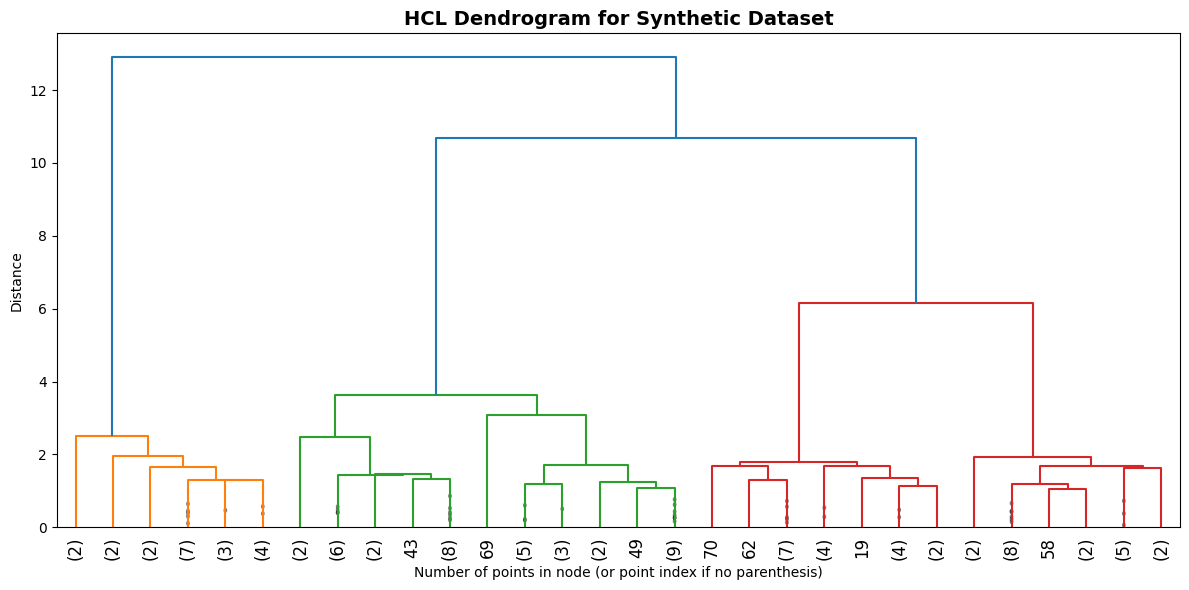

In [44]:
# ==========================================
# 1. Evaluate Model at K Clusters (Original)
# ==========================================
start_time_hull_cen_linkage = time.time()
hull_cen_model = HullCentroidLinkage(n_clusters=k)
labels_hull_cen = hull_cen_model.fit_predict(X)
end_time_hull_cen_linkage = time.time()

eval_hull_cen_linkage = Evaluate("Hull Centroid Linkage", X, true_labels, labels_hull_cen).metrics_()
evaluation_table.append(eval_hull_cen_linkage)

time_hull_cen_linkage= (end_time_hull_cen_linkage - start_time_hull_cen_linkage)


# ==========================================
# 2. View Dendrogram (Requires n_clusters=1)
# ==========================================
# Run it again until 1 cluster remains to build the full tree history
hull_cen_dendro_model = HullCentroidLinkage(n_clusters=1)
hull_cen_dendro_model.fit_predict(X)

# Call the custom plotting function
hcl_dendro_plot = plot_custom_dendrogram(
    hull_cen_dendro_model.merge_history,
    p=30, # Change this to show more or fewer top branches
    title=f"HCL Dendrogram for Synthetic Dataset"
)

# Save the plot (using your existing saveplotpath and dpi variables)
hcl_dendro_plot.savefig(f'hcl_dendrogram_plot.png', dpi=300)

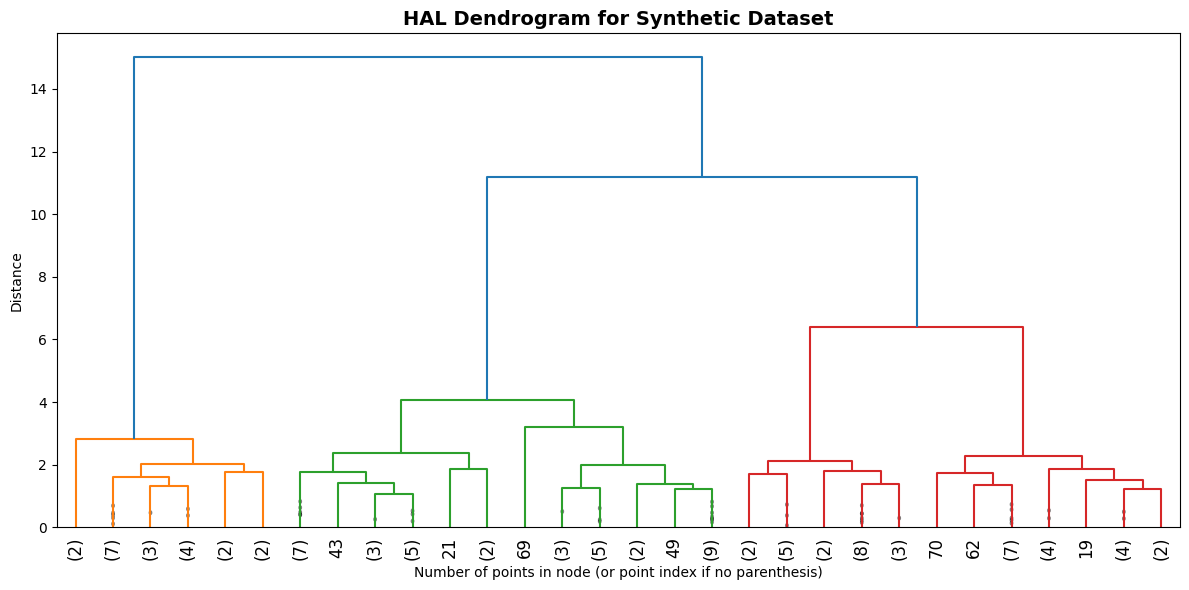

In [43]:
# ==========================================
# 1. Evaluate Model at K Clusters (Original)
# ==========================================
start_time_hull_avg_linkage = time.time()
hull_avg_model = HullAverageLinkage(n_clusters=k)
labels_hull_avg = hull_avg_model.fit_predict(X)
end_time_hull_avg_linkage = time.time()

eval_hull_avg_linkage = Evaluate("Hull Average Linkage", X, true_labels, labels_hull_avg).metrics_()
evaluation_table.append(eval_hull_avg_linkage)

time_hull_avg_linkage= (end_time_hull_avg_linkage - start_time_hull_avg_linkage)


# ==========================================
# 2. View Dendrogram (Requires n_clusters=1)
# ==========================================
# Run it again until 1 cluster remains to build the full tree history
hull_avg_dendro_model = HullAverageLinkage(n_clusters=1)
hull_avg_dendro_model.fit_predict(X)

# Call the custom plotting function
hal_dendro_plot = plot_custom_dendrogram(
    hull_avg_dendro_model.merge_history,
    p=30, # Change this to show more or fewer top branches
    title=f"HAL Dendrogram for Synthetic Dataset"
)

# # Save the plot
hal_dendro_plot.savefig(f'hal_dendrogram_plot.png', dpi=300)

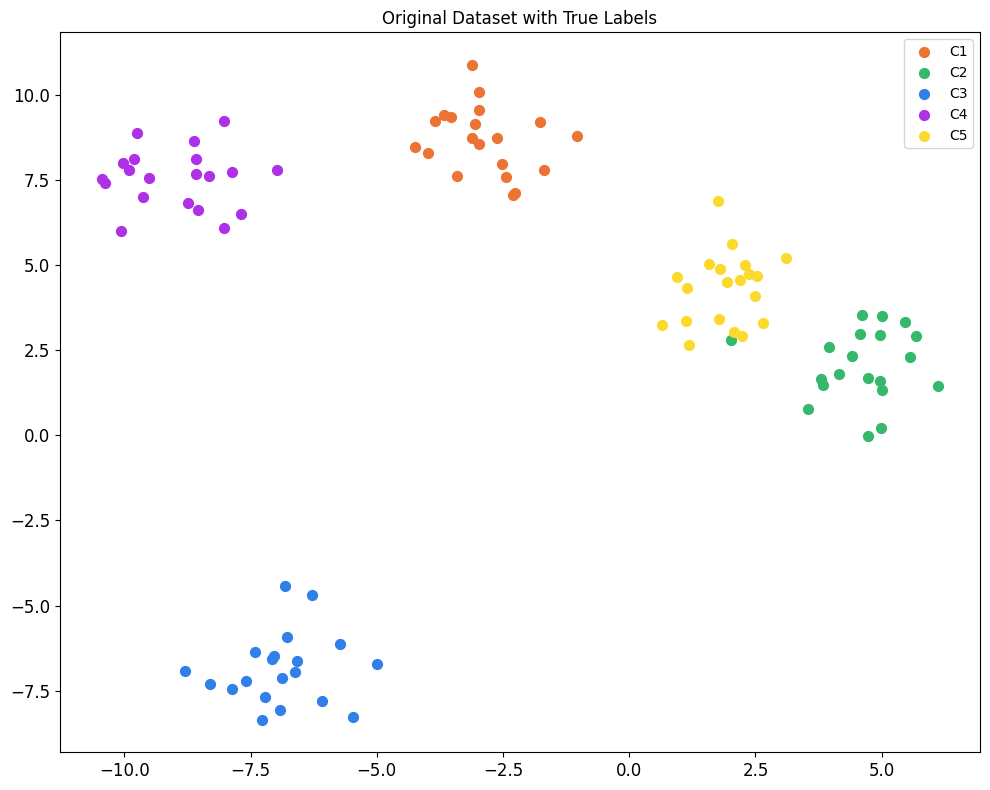

In [42]:
# Parameters for customization
point_size = 50  # Increased point size
tick_label_size = 12 # Increased tick label size

# Replicating Plot.plot_final_clusters logic with customizations
plot_X = np.asarray(X)
plot_labels = np.asarray(true_labels)
plot_title = "Original Dataset with True Labels"

unique_labels = np.unique(plot_labels)
n_clusters = len(unique_labels)
n_features = plot_X.shape[1]

# Use existing default colors, extending if necessary
colors = Plot.DEFAULT_COLORS
if len(colors) < n_clusters:
    colors = Plot._extend_colors(n_clusters, colors)
cluster_cmap = ListedColormap(colors[:n_clusters])

fig = plt.figure(figsize=(10, 8)) # Default figsize from Plot class
ax = fig.add_subplot(111) # Assuming 2D for this dataset

for i, lab in enumerate(unique_labels):
    pts = plot_X[plot_labels == lab]
    ax.scatter(pts[:, 0], pts[:, 1], s=point_size, alpha=1, color=cluster_cmap(i), label=f"C{lab+1}")

ax.set_title(plot_title)
ax.legend()

# Increase tick label sizes
ax.tick_params(axis='x', labelsize=tick_label_size)
ax.tick_params(axis='y', labelsize=tick_label_size)

plt.tight_layout()
plt.show()

# Save the plot (ensure saveplotpath and dpi are defined in previous cells)
original_data_true_labels_plot_custom = fig
if 'saveplotpath' in globals() and 'dpi' in globals():
    original_data_true_labels_plot_custom.savefig(f'{saveplotpath}_original_data_true_labels_plot_custom.png', dpi=dpi)
else:
    print("Warning: saveplotpath or dpi not defined. Plot not saved.")


original_data_true_labels_plot_custom.savefig(f'scatter_random.png', dpi=300)

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy

def plot_simplified_dendrogram(X, method='ward', p=30, title="Simplified Dendrogram", figsize=(12, 6)):
    """
    Generates a simplified dendrogram for large datasets.

    Parameters:
    - X: The feature array/dataset.
    - method: The linkage method to use ('ward', 'single', 'complete', 'average').
    - p: The number of top clusters/leaves to display.
    - title: Title of the plot.
    - figsize: Figure size (width, height).
    """
    X = np.asarray(X)

    # Calculate the standard linkage matrix
    Z = hierarchy.linkage(X, method=method, metric='euclidean')

    fig = plt.figure(figsize=figsize)
    plt.title(title, fontsize=14, fontweight='bold')

    # The x-axis will show cluster sizes in parentheses
    plt.xlabel("Number of points in node (or point index if no parenthesis)", fontsize=10)
    plt.ylabel("Distance", fontsize=10)

    # Generate the truncated dendrogram
    hierarchy.dendrogram(
        Z,
        truncate_mode='lastp',  # Show only the last 'p' merged clusters
        p=p,                    # Target number of leaves
        leaf_rotation=90.,      # Rotate labels for readability
        leaf_font_size=12.,
        show_contracted=True    # Places a dot to indicate a truncated branch
    )

    plt.tight_layout()
    plt.show()
    return fig

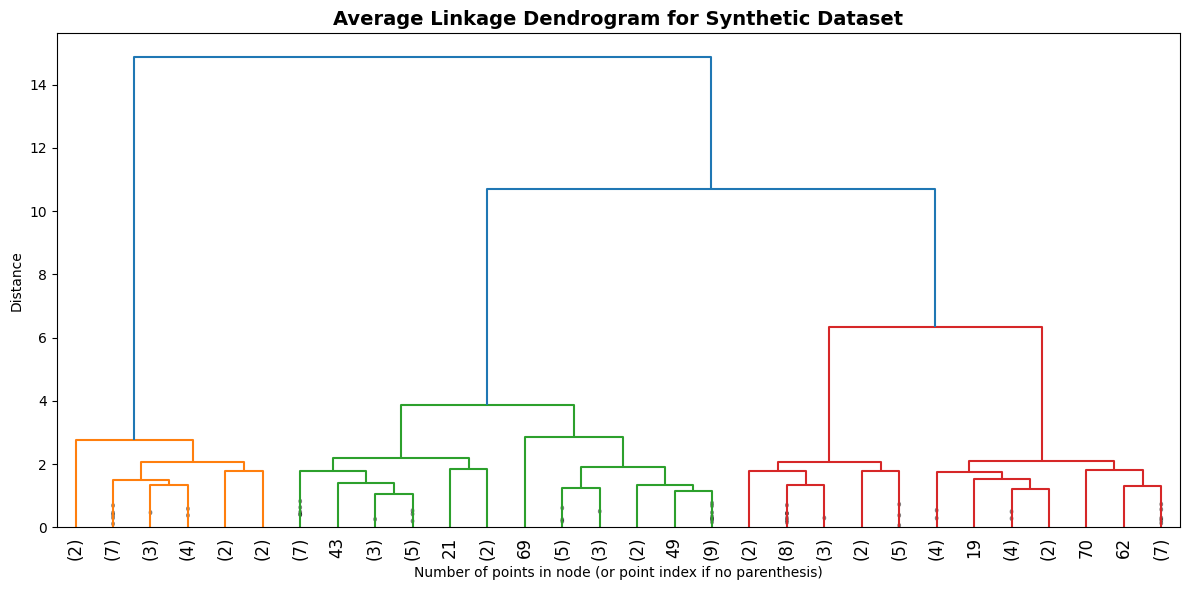

In [41]:
avg_dendrogram_plot = plot_simplified_dendrogram(
    X,
    method='average',
    p=30,
    title=f"Average Linkage Dendrogram for Synthetic Dataset"
)

# Save the plot
avg_dendrogram_plot.savefig(f'average_dendrogram_plot.png', dpi=300)